#“US Superstore  data”

In [45]:
# imports

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ipywidgets import interact  #interactive
import seaborn as sns

# Function for formatting thousands with a period
def format_miles(x, _):
    return f"{int(x):,}".replace(",", ".")

1. Data Preparation:

Download and explore the **US Superstore data**.

Perform basic data cleaning and preprocessing.

In [46]:
uploaded = files.upload()

Saving US Superstore data.xls to US Superstore data (2).xls


In [47]:
df = pd.read_excel('US Superstore data.xls')

print(f'Size of dataset: {df.shape[0]} rows x  {df.shape[1]} columns')

print("\nFirst 5 rows:")
print(df.head())

print("\nSummary on columns names, nulls and data types\n")
print(df.info())

Size of dataset: 9994 rows x  21 columns

First 5 rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         C

#Data Cleaning

In [48]:
# == Rename columns to snake_case  ==
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)

In [49]:
print("\nDataset columns:")   #names ok
print(df.columns)


Dataset columns:
Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [50]:
# == Check duplicates==
print(f'\nDuplicate rows: {df.duplicated().sum()}')

print(f'\nThere are no duplicate records in the dataframe')


Duplicate rows: 0

There are no duplicate records in the dataframe


In [51]:
# == Check missing values ==
print(df.isnull().sum())

print(f'\nThere are no missing values in the dataframe')

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

There are no missing values in the dataframe


In [52]:
# == # Extract year for temporal analysis in columns order and ship dates ==
df["year_order"] = df["order_date"].dt.year
df["year_ship"] = df["ship_date"].dt.year

In [53]:
# -----------------------------
# Transformation of Data Types
# -----------------------------

# postal code Not numeric
df['postal_code'] = df['postal_code'].astype('string').str.replace('.0', '', regex=False).str.zfill(5)

# Convert to categorical columns
categorical_cols = ['ship_mode', 'segment', 'country', 'city', 'state', 'region', 'category', 'sub_category']
df[categorical_cols] = df[categorical_cols].astype('category')

#convert id and text types to string
id_cols = ['customer_id', 'product_id']
text_cols = ['customer_name', 'product_name', 'postal_code']

df[id_cols + text_cols] = df[id_cols + text_cols].astype('string')

# checking
print(df.dtypes)


row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode              category
customer_id      string[python]
customer_name    string[python]
segment                category
country                category
city                   category
state                  category
postal_code      string[python]
region                 category
product_id       string[python]
category               category
sub_category           category
product_name     string[python]
sales                   float64
quantity                  int64
discount                float64
profit                  float64
year_order                int32
year_ship                 int32
dtype: object


In [54]:
#Checking Postal Code = 05408

df.loc[df['state'] == 'Vermont', 'postal_code'].unique()


<StringArray>
['05408']
Length: 1, dtype: string

# Analysis

2.1 Sales Trend Over Years (Matplotlib + Slider)

In [62]:
# Aggregate sales by year
sales_by_year = df.groupby('year_order')['sales'].sum().reset_index()

def plot_sales(year_min, year_max):
    filtered = sales_by_year[(sales_by_year['year_order'] >= year_min) & (sales_by_year['year_order'] <= year_max)]

    plt.figure(figsize=(10,5))
    plt.plot(filtered['year_order'], filtered['sales'], marker='o', color='blue')
    plt.title("Sales Trend Over Years")
    plt.xlabel("Year")
    plt.ylabel("Total Sales (USD)")
    plt.xticks(filtered['year_order'])
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_miles))
    plt.grid(True)
    plt.show()

#For basic interaction it is used ipywidgets
interact(plot_sales, year_min=(2014,2017), year_max=(2014,2017))



interactive(children=(IntSlider(value=2015, description='year_min', max=2017, min=2014), IntSlider(value=2015,…

<function __main__.plot_sales(year_min, year_max)>

👉 Insight:

Clearly upward trend.

After a slight dip in 2015, growth is consistent and accelerating.
This setback does not appear to be structural because it has recovered strongly.

The business ended 2017 much larger than it started.

2.2. Sales by Country (Matplotlib)

/tmp/ipython-input-730/1817819130.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_country = df.groupby('country')['sales'].sum().reset_index()


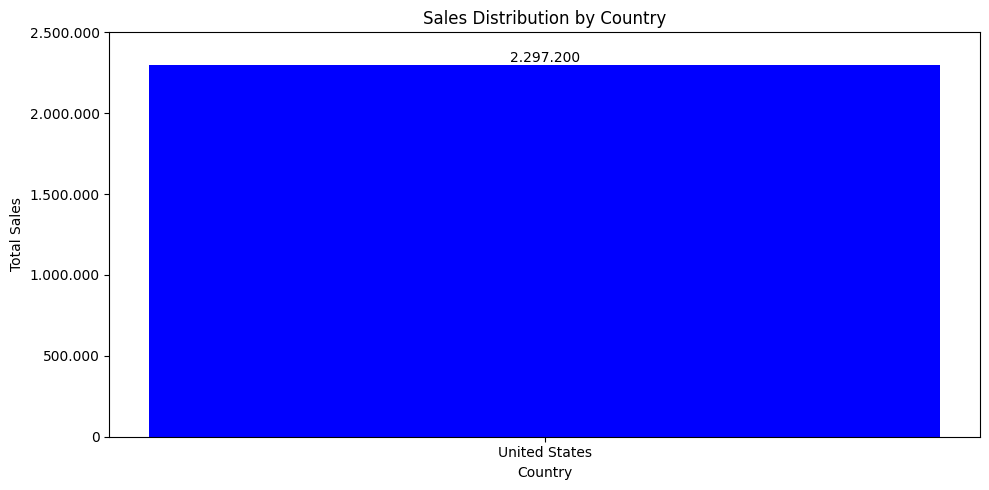

Dataset contains only the United States, so no country variation available.


In [63]:
# Aggregate sales by country
sales_by_country = df.groupby('country')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
bars = plt.bar(sales_by_country['country'], sales_by_country['sales'], color='blue')

plt.title("Sales Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_miles))
plt.ylim(0, 2500000)

# Values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}'.replace(',', '.'), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Dataset contains only the United States, so no country variation available.")

👉 Insight:

Since there is no variation in the country column, it is not possible
to create an interactive map or slider by country using Matplotlib.

A static bar chart is used instead to represent the sales distribution (United States = 100%).

3.1. Top 10 Products by Sales (Seaborn)


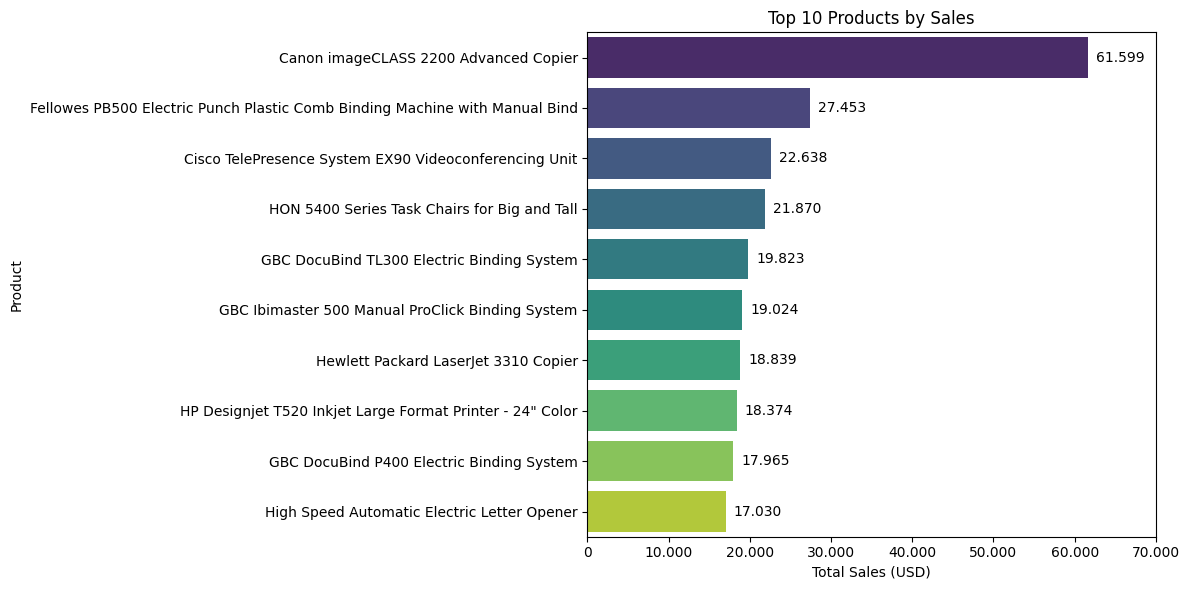

In [66]:
sales_by_product = df.groupby('product_name')['sales'].sum().reset_index()

top10 = sales_by_product.sort_values(by='sales', ascending=False).head(10)

plt.figure(figsize=(12,6))

bars = sns.barplot(
    data=top10,
    y='product_name',
    x='sales',
    hue='product_name',  # avoid warning
    palette='viridis',
    orient='h',
    dodge=False,
    legend=False
)

plt.xlim(0, 70000)  #x-axis format
bars.xaxis.set_major_formatter(FuncFormatter(format_miles))  #x-axis format

# Values at the end of each bar
for patch in bars.patches:
    width = patch.get_width()
    plt.text(
        width + 1000,
        patch.get_y() + patch.get_height()/2,
        f'{int(width):,}'.replace(',', '.'),
        ha='left',
        va='center'
    )

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [58]:
total_sales = sales_by_product['sales'].sum()

sales_by_product = sales_by_product.sort_values(by='sales', ascending=False)

sales_by_product['pct_of_total'] = sales_by_product['sales'] / total_sales
sales_by_product['cum_pct'] = sales_by_product['pct_of_total'].cumsum()

top10 = sales_by_product.head(10)

top10_total_pct = top10['pct_of_total'].sum()

print(f"Top 10 contribution: {top10_total_pct:.2%}")

Top 10 contribution: 10.65%


In [59]:
product_summary = (
    df.groupby('product_name')
      .agg({
          'sales': 'sum',
          'profit': 'sum'
      })
      .reset_index()
)

# sort by sales
product_summary = product_summary.sort_values(by='sales', ascending=False)

#Top 10 best sellers
top10 = product_summary.head(10).copy()

# Profitability index (margin)
top10['profit_margin'] = top10['profit'] / top10['sales']

# sort columns
top10 = top10[['product_name', 'sales', 'profit', 'profit_margin']]

top10['sales'] = top10['sales'].apply(lambda x: f"{x:,.0f}".replace(",", "."))
top10['profit'] = top10['profit'].apply(lambda x: f"{x:,.0f}".replace(",", "."))
top10['profit_margin'] = top10['profit_margin'].apply(lambda x: f"{x:.2%}")

top10




,product_name,sales,profit,profit_margin
404,Canon imageCLASS 2200 Advanced Copier,61.600,25.200,40.91%
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27.453,7.753,28.24%
444,Cisco TelePresence System EX90 Videoconferenci...,22.638,-1.811,-8.00%
786,HON 5400 Series Task Chairs for Big and Tall,21.871,0,0.00%
686,GBC DocuBind TL300 Electric Binding System,19.823,2.234,11.27%
688,GBC Ibimaster 500 Manual ProClick Binding System,19.024,761,4.00%
805,Hewlett Packard LaserJet 3310 Copier,18.840,6.984,37.07%
787,HP Designjet T520 Inkjet Large Format Printer ...,18.375,4.095,22.29%
683,GBC DocuBind P400 Electric Binding System,17.965,-1.878,-10.45%
813,High Speed Automatic Electric Letter Opener,17.030,-262,-1.54%


👉 Insight:

Sales are not concentrated in just a few products (Top 10: 10.65% sales accumulation).

Between the 10 best-selling products, 4 have a non-positive margin. The best-selling product is not always the most profitable.

3.2. Profit vs Discount (Scatter)

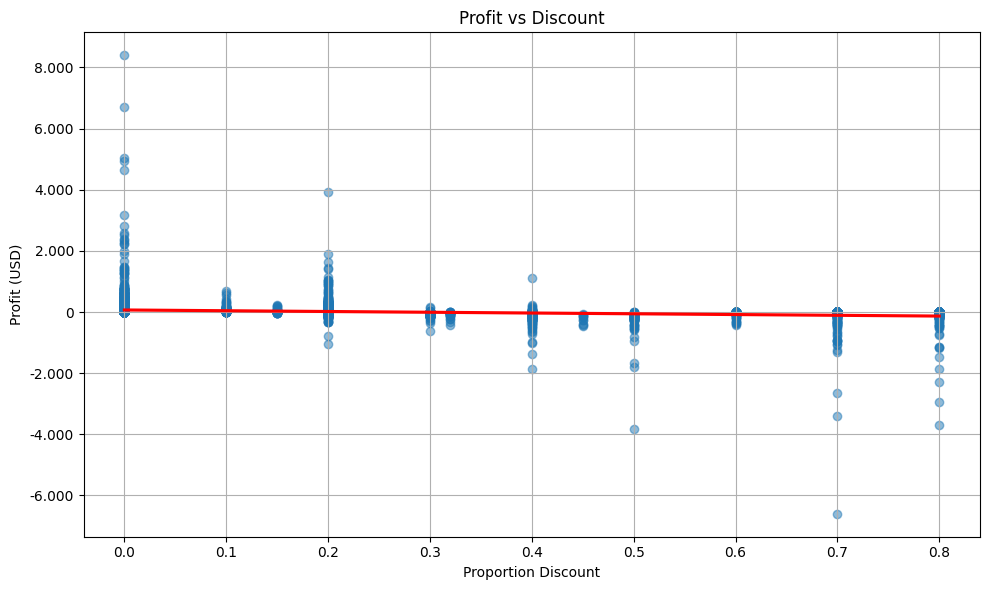

In [67]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x='discount', y='profit', scatter=True,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Profit vs Discount")
plt.xlabel("Proportion Discount")
plt.ylabel("Profit (USD)")
plt.grid(True)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_miles))  #y-axis format
plt.tight_layout()
plt.show()


In [61]:
# Correlation coefficient
correlation = df['profit'].corr(df['discount'])
print(f"Correlation between Profit and Discount: {correlation:.4f}")


Correlation between Profit and Discount: -0.2195


👉 Insight:

Larger discounts tend to reduce profit. (negative relationship).

4. Comparative Analysis


---



* **Matplotlib**: Flexible and highly customizable. Good for interactive plots (sliders, zoom) and precise control over axes, labels, and formatting. Requires more code for styling and annotations.

* **Seaborn**: Built on Matplotlib, but simpler for statistical visualizations. Easy to add regression lines, group by categories, and apply color palettes. Produces clean and readable plots with less code.

**Conclusion**: Matplotlib is best for flexibility and custom interactivity, while Seaborn is faster and better for exploring statistical patterns. For real dashboards  I would migrate to Plotly or Power BI.